# Physique des marchés
## TP2.3 : Etats de marché

### Par : Adonis JAMAL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from collections import Counter
from xgboost import XGBClassifier

from clustering_correlation_Leiden import compute_filtered_C, LeidenCorrelationClustering

---
### 1. Détermination d'états de marché

1. Charger les données de rendement US.

In [2]:
returns = pd.read_parquet("../data/sp500_20161229.parquet", engine="pyarrow")
returns["index"] = pd.to_datetime(returns["index"])
returns.set_index("index", inplace=True)
returns.head()

,A,AA,AABA,ABC,ABT,ADBE,ADI,ADP,ADSK,AEE,...,WU,WY,XEL,XL,XLNX,XOM,XRX,YUM,ZBH,ZION
index,,,,,,,,,,,,,,,,,,,,,
2006-01-03,0.006308,0.011160,0.044155,0.020773,0.003043,0.049784,0.023139,0.009368,-0.004657,0.012100,...,NaN,0.004522,0.005959,0.012615,0.022213,0.040947,0.017747,-0.002773,0.015421,0.012176
2006-01-04,0.002687,0.005686,0.001467,-0.006626,0.001517,-0.009794,0.009264,0.003238,-0.005951,-0.005013,...,NaN,0.024160,0.004847,0.020519,0.044610,0.001710,-0.001341,0.008556,0.009492,0.007061
2006-01-05,0.026198,0.007981,0.013669,-0.012387,0.010856,-0.009110,0.031857,-0.008391,-0.014722,-0.008527,...,NaN,-0.008791,-0.000536,-0.001867,0.060566,-0.004951,-0.010745,0.042630,-0.010560,0.009089
2006-01-06,0.005222,-0.003299,0.040453,-0.011095,0.021229,0.024429,0.003925,0.008679,0.057798,0.014660,...,NaN,0.001478,0.003753,0.001583,0.019615,0.019732,-0.006110,-0.002848,-0.005117,0.010422
2006-01-09,-0.002886,0.011255,0.004860,0.000000,0.037173,-0.015641,0.014073,-0.002581,-0.014676,-0.004816,...,NaN,-0.002362,-0.002671,0.006752,-0.000687,-0.000505,0.013661,0.007752,0.035415,-0.008277


2. Choisir une taille de fenêtre de calibration $T$.

In [4]:
T = 120

3. Choisir un univers de titres (colonnes). Rappel : pour la détermination des états de marché, $N > T$ est indispensable.

In [5]:
N = 200

ticker_rank = returns.notna().mean().sort_values(ascending=False)
tickers = ticker_rank.index[:N]

4. Pour chaque fenêtre de calibration

(a). Supprimez les colonnes avec des NA

In [6]:
dT = 5
window_end_idx = range(T - 1, len(returns), dT)
clean_windows = []
window_end_dates = []

for end_idx in window_end_idx:
    start_idx = end_idx - T + 1
    r = returns.iloc[start_idx:end_idx + 1][tickers].dropna(axis=1)
    if r.shape[1] > T:
        clean_windows.append(r)
        window_end_dates.append(returns.index[end_idx])

len(clean_windows)

606

(b). Appliquez l'algorithme de Leiden selon la méthode de MacMahon et Garlaschelli pour obtenir les états $\mu_t, t \in {t_0, \ldots, t_1}$

In [7]:
clusterings = []
state_counts = []

for r in clean_windows:
    # Correlation matrix filtered with MacMahon-Garlaschelli
    C_s = compute_filtered_C(r.values)
    try: labels = LeidenCorrelationClustering(C_s)
    except ValueError: labels = np.zeros(r.shape[1], dtype=int)

    clustering = pd.Series(labels, index=r.columns, name="cluster")
    clusterings.append(clustering)
    state_counts.append(clustering.nunique())

market_states = pd.Series(clusterings, index=window_end_dates, name="mu_t")
state_count_series = pd.Series(state_counts, index=window_end_dates, name="n_states")
state_count_series.head()

2006-06-23    3
2006-06-30    2
2006-07-10    2
2006-07-17    2
2006-07-24    3
Name: n_states, dtype: int64

5. Tracez le nombre d'états de marché en fonction du temps $t_1$, en décalant les fenêtres de calibration de $d T$ jours.

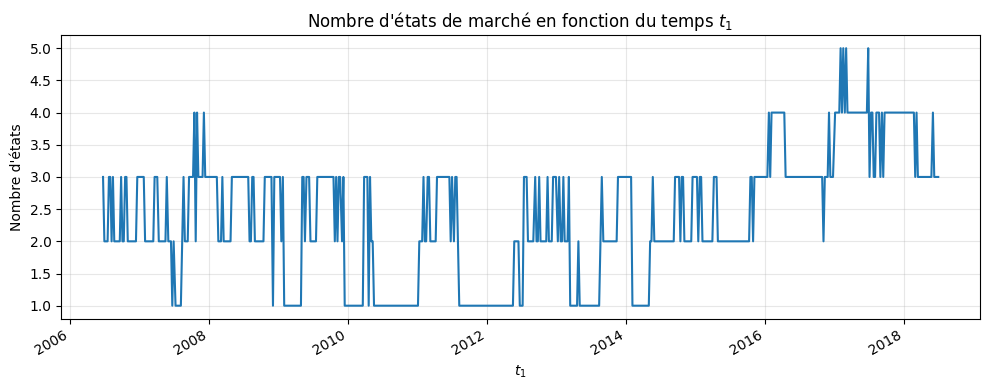

In [8]:
plt.figure(figsize=(10, 4))
state_count_series.plot()
plt.title("Nombre d'états de marché en fonction du temps $t_1$")
plt.xlabel("$t_1$")
plt.ylabel("Nombre d'états")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

6. Tracer l'adjusted Rand index entre deux clustering consécutifs en fonction du temps. Commenter l'évolution de la structure de marché au regard du seuil de significativité des ARIs trouvées.

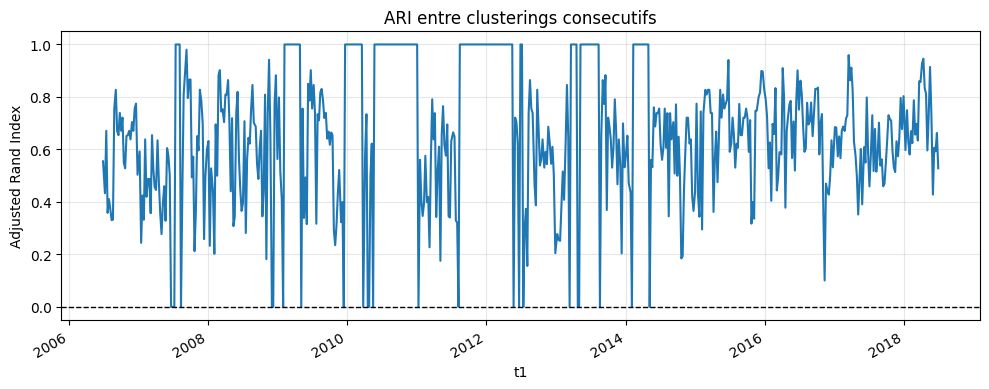

count    605.000000
mean       0.671410
std        0.259091
min        0.000000
25%        0.519327
50%        0.686362
75%        0.866405
max        1.000000
Name: ARI, dtype: float64

In [9]:
ari_values = []
ari_dates = []

for i in range(1, len(clusterings)):
    prev_c = clusterings[i - 1]
    curr_c = clusterings[i]
    common = prev_c.index.intersection(curr_c.index)
    if len(common) < 2:
        continue
    ari_values.append(adjusted_rand_score(prev_c.loc[common], curr_c.loc[common]))
    ari_dates.append(window_end_dates[i])

ari_series = pd.Series(ari_values, index=ari_dates, name="ARI")

plt.figure(figsize=(10, 4))
ari_series.plot()
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("ARI entre clusterings consecutifs")
plt.xlabel("t1")
plt.ylabel("Adjusted Rand Index")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ari_series.describe()

<blockquote>

Avec une moyenne de $0.67$ et une médiane de $0.69$, la structure de marché (la composition des clusters/secteurs) d'une fenêtre à l'autre possède une forte mémoire. Les secteurs restent cohérents d'une semaine à l'autre et la structure du marché n'est donc pas aléatoire. On remarque notamment que $75\%$ des ARIs sont supérieurs à $0.51$, ce qui signifie que la classification reste très cohérente d'une semaine à l'autre.

Les chutes brutales de l'indice AI marquent des crises macroéconomiques (2008, 2011). Lors d'une panique, toutes les actions évoluent ensemble, ce qui détruit la structure sectorielle du marché. Le clustering au temps $t$ est alors très différent de celui au temps $t-1$, d'où une chute de l'ARI.

Quand $ARI=1$, on observe que le nombre d'états vaut souvent $1$, mathématiquement on a une partition identique et dégénérée (un seul cluster). Financièrement, cela traduit un régime de corrélation quasi totale où le facteur de marché domine: la diversification intra-marché devient très faible et les titres bougent presque en bloc.

Le marché alterne donc entre des régimes calmes et bien structurés (ARI élevé) et des périodes de stress financier où cette structure se désintègre totalement (ARI faible).

</blockquote>

---
### 2. Stratégies basées sur les états de marché (à choix avec 3)

Il s'agit d'inventer des stratégies qui exploitent les états de marchés.

1. Pour une fenêtre temporelle de longueur bien choisie, déterminer les états de marchés.

In [10]:
print(f"T = {T} days, N = {N} tickers, dT = {dT} days")
print(f"Period Covered: {window_end_dates[0].date()} to {window_end_dates[-1].date()}")
print(f"Number of calibration windows: {len(clusterings)}")
      
print("\nDistribution of the number of market states:")
state_count_series.describe()

T = 120 days, N = 200 tickers, dT = 5 days
Period Covered: 2006-06-23 to 2018-06-29
Number of calibration windows: 606

Distribution of the number of market states:


count    606.000000
mean       2.346535
std        0.981842
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: n_states, dtype: float64

2. Etant donné l’état de marché du dernier pas temporel de la fenêtre de calibration, trouver un critère pour déterminer dans quels titres investir. Note : on peut imaginer tenir la position un jour, ou plus.

In [11]:
def cluster_momentum(r_window, clustering, lookback=20):
    lookback = min(lookback, len(r_window))
    recent = r_window.iloc[-lookback:]
    scores = {}
    for c in clustering.unique():
        stocks = clustering[clustering == c].index.intersection(recent.columns)
        if len(stocks) > 0:
            scores[c] = recent[stocks].mean().mean()
    return pd.Series(scores)

print("Scores for the last window:")
scores = cluster_momentum(clean_windows[-1], clusterings[-1])
scores.sort_values(ascending=False)

Scores for the last window:


0    0.000311
2    0.000254
1    0.000224
dtype: float64

3. Pour appliquer cette stratégie les jours suivants, trois possibilités,

(a) décaler la fenêtre temporelle de 1 pas et appliquer les points ci-dessus ;

(b) utiliser une approche des plus proches voisins par rapport aux rendements moyens d’un état de marché ;

(c) un mélange des deux

<blockquote>

Nous allons utiliser l'approche (c).

</blockquote>

In [12]:
k_neighbors = 3
strategy_daily_rets = {}
selected_cluster_sizes = []

for i in range(len(clusterings)):
    date_t1 = window_end_dates[i]
    cl = clusterings[i]

    # Current window: best cluster by momentum
    scores = cluster_momentum(clean_windows[i], cl)
    best = scores.idxmax()
    current_stocks = set(cl[cl == best].index)

    # NN: gather best-cluster stocks from k recent past windows
    neighbors = range(max(0, i - k_neighbors), i)
    neighbor_stocks = []
    for j in neighbors:
        sj = cluster_momentum(clean_windows[j], clusterings[j])
        bj = sj.idxmax()
        neighbor_stocks.extend(clusterings[j][clusterings[j] == bj].index)

    # Merge: current selection + robust picks across recent windows
    if neighbor_stocks:
        counts = Counter(neighbor_stocks)
        robust = {s for s, cnt in counts.items() if cnt >= max(1, len(list(neighbors)) // 2)}
        selected = list(current_stocks | (robust & set(cl.index)))
    else:
        selected = list(current_stocks)

    selected_cluster_sizes.append(len(selected))

    # Forward returns for next dT days
    idx_t1 = returns.index.get_loc(date_t1)
    for d in range(1, dT + 1):
        if idx_t1 + d >= len(returns):
            break
        fwd_date = returns.index[idx_t1 + d]
        avail = returns.loc[fwd_date, selected].dropna()
        if len(avail) > 0:
            strategy_daily_rets[fwd_date] = avail.mean()

strategy_series = pd.Series(strategy_daily_rets).sort_index()
strategy_series = strategy_series[~strategy_series.index.duplicated(keep='last')]
print(f"Strategy: {len(strategy_series)} trading days, avg portfolio size: {np.mean(selected_cluster_sizes):.0f} stocks")

Strategy: 3025 trading days, avg portfolio size: 160 stocks


4. Calculer la performance cumulée de cette stratégies (avec au moins $100$ fenêtres de calibration).

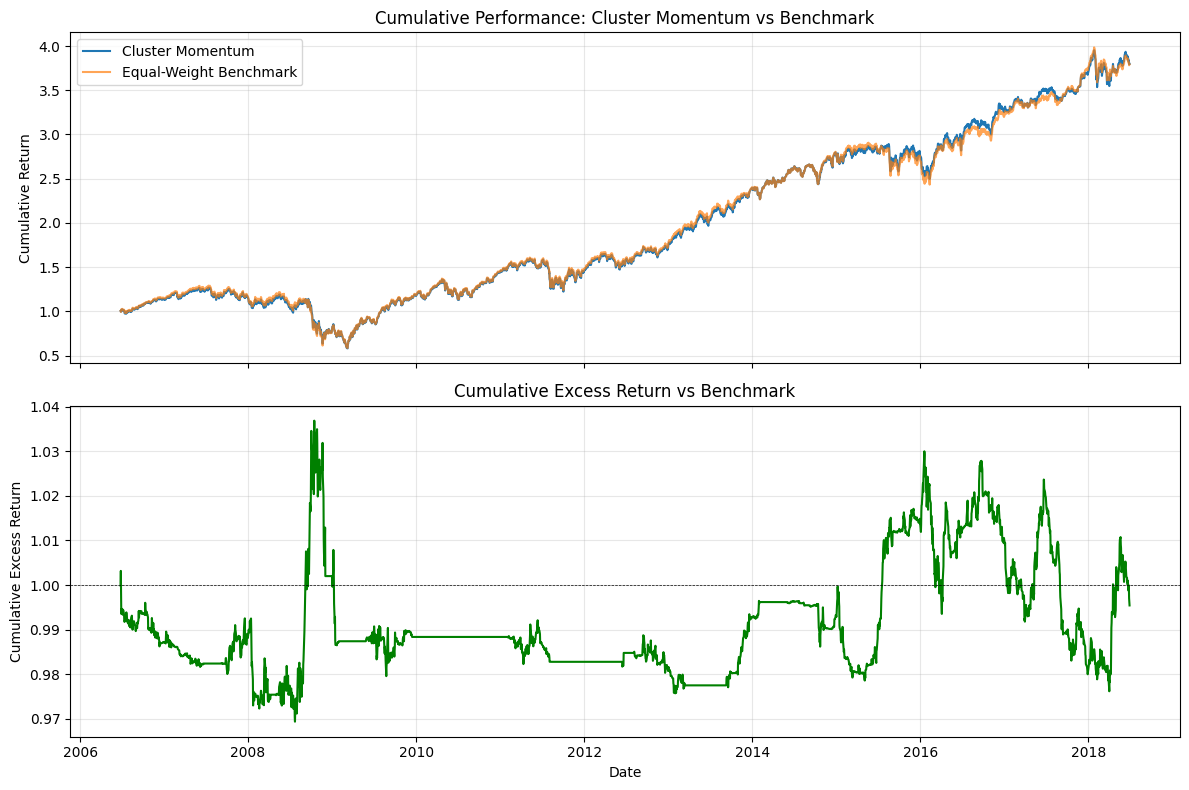

Strategy Total Return: 279.80%
Benchmark Total Return: 279.36%
Strategy Sharpe Ratio: 0.63
Calibration windows: 606


In [13]:
bm_rets = returns[tickers].mean(axis=1).loc[strategy_series.index]
cum_strategy = (1 + strategy_series).cumprod()
cum_bm = (1 + bm_rets).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_strategy.index, cum_strategy.values, label="Cluster Momentum")
axes[0].plot(cum_bm.index, cum_bm.values, label="Equal-Weight Benchmark", alpha=0.7)
axes[0].set_ylabel("Cumulative Return")
axes[0].set_title("Cumulative Performance: Cluster Momentum vs Benchmark")
axes[0].legend()
axes[0].grid(alpha=0.3)

excess = strategy_series - bm_rets
cum_excess = (1 + excess).cumprod()
axes[1].plot(cum_excess.index, cum_excess.values, color="green")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=0.5)
axes[1].set_ylabel("Cumulative Excess Return")
axes[1].set_xlabel("Date")
axes[1].set_title("Cumulative Excess Return vs Benchmark")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

total_ret = cum_strategy.iloc[-1] - 1
bm_ret = cum_bm.iloc[-1] - 1
sharpe = strategy_series.mean() / strategy_series.std() * np.sqrt(252)
print(f"Strategy Total Return: {total_ret:.2%}")
print(f"Benchmark Total Return: {bm_ret:.2%}")
print(f"Strategy Sharpe Ratio: {sharpe:.2f}")
print(f"Calibration windows: {len(clusterings)}")

<blockquote>

comment

</blockquote>

---
### 3. Prédiction de la direction d'un titre financier avec l'apprentissage de la machine (à choix avec 2)

Le but est d'utiliser l'apprentissage machine pour trouver une stratégie qui exploite les états de marché.

1. Choisir un titre (une colonne) dont prédire les rendements $R_{t+1}$ au temps $t$.

In [14]:
ticker = "MSFT"
K = 5

2. Pour chaque fenêtre temporelle de calibration ${t_0, t_1}$, construire une matrice de predicteurs à partir des $K$ derniers états de marché (et éventuellement d'autres prédicteurs)

$$P_{t_0,t_1} = \begin{pmatrix} \mu_{t_0+K-1} & \mu_{t_0+K-2} & \cdots & \mu_{t_0} \\ \vdots & \vdots & & \vdots \\ \mu_{t_1} & \mu_{t_1-1} & \cdots & \mu_{t_1-K+1} \end{pmatrix}$$

In [15]:
def encode_state(r_window, clustering, tk):
    n = clustering.nunique()
    if tk in clustering.index:
        tc = clustering[tk]
        members = clustering[clustering == tc].index.intersection(r_window.columns)
        frac = len(members) / len(clustering)
        mean_ret = r_window[members].iloc[-20:].mean().mean() if len(members) > 0 else 0.0
    else:
        frac, mean_ret = 0.0, 0.0
    return [n, frac, mean_ret]

state_features = np.array([
    encode_state(clean_windows[i], clusterings[i], ticker)
    for i in range(len(clusterings))
])

X_all, y_all, pred_indices = [], [], []
for i in range(K, len(clusterings)):
    row = np.concatenate([state_features[i - k] for k in range(K)])
    t1 = window_end_dates[i]
    idx = returns.index.get_loc(t1)
    if idx + 1 < len(returns):
        r_next = returns.iloc[idx + 1][ticker]
        if not np.isnan(r_next):
            X_all.append(row)
            y_all.append(1 if r_next >= 0 else -1)
            pred_indices.append(i)

X_all = np.array(X_all)
y_all = np.array(y_all)
print(f"Predictor matrix: {X_all.shape} (features per state: 3, K={K} lags)")

Predictor matrix: (600, 15) (features per state: 3, K=5 lags)


3. Utiliser un paquet d’apprentissage machine (e1071, randomForestSRC, scikit-learn, etc.) de votre langage préféré et pour chaque t, apprendre le signe des rendements de R

$$\begin{pmatrix} \mu_{t_0+K-1} & \cdots & \mu_{t_0} \\ \vdots & & \vdots \\ \mu_{t_1-1} & \cdots & \mu_{t_1-K} \end{pmatrix} \sim \begin{pmatrix} \operatorname{sign} R_{t_0+K} \\ \vdots \\ \operatorname{sign} R_{t_1} \end{pmatrix}$$

Notez que la dernière ligne de $P_{t_0,t_1}$ est gardée en réserve pour la prédiction $R_{t_1+1}$

In [16]:
min_train = 50
raw_predictions = {}

# XGBoost expects labels {0, 1}
y_xgb = (y_all + 1) // 2

for t in range(min_train, len(X_all)):
    clf = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                        eval_metric="logloss", random_state=42, verbosity=0)
    clf.fit(X_all[:t], y_xgb[:t])
    pred = clf.predict(X_all[t:t+1])[0]
    pred = 1 if pred == 1 else -1

    wi = pred_indices[t]
    t1 = window_end_dates[wi]
    idx_t1 = returns.index.get_loc(t1)

    # Hold position for dT days
    for d in range(1, dT + 1):
        if idx_t1 + d < len(returns):
            fwd_date = returns.index[idx_t1 + d]
            r_actual = returns.loc[fwd_date, ticker]
            if not np.isnan(r_actual):
                raw_predictions[fwd_date] = (pred, r_actual)

print(f"Predictions for {len(raw_predictions)} trading days")

Predictions for 2750 trading days


4. Prédire $\operatorname{sign} R_{t_1 + 1}$ (fonction predict appliquée à la dernière ligne de $P_{t_0,t_1}$)

In [17]:
pred_df = pd.DataFrame(raw_predictions, index=["x_t", "r_t"]).T
pred_df = pred_df[~pred_df.index.duplicated(keep='last')].sort_index()

accuracy = (np.sign(pred_df["r_t"]) == pred_df["x_t"]).mean()
print(f"Directional accuracy: {accuracy:.2%}")
pred_df.head()

Directional accuracy: 50.29%


,x_t,r_t
2007-07-31,-1.0,-0.013946
2007-08-01,-1.0,0.010693
2007-08-02,-1.0,0.007509
2007-08-03,-1.0,-0.018967
2007-08-06,-1.0,0.020024


5. Notez cette prédiction $x_{t_1+1}$. C'est également le pari à prendre au temps $t_1$, donc le rendement est $g_{t_1} = x_{t_1 + 1} r_{t_1 + 1}$.

In [18]:
pred_df["g_t"] = pred_df["x_t"] * pred_df["r_t"]
print(f"Mean daily g_t: {pred_df['g_t'].mean():.6f}")
pred_df["g_t"].describe()

Mean daily g_t: 0.000089


count    2750.000000
mean        0.000089
std         0.017496
min        -0.117131
25%        -0.007973
50%         0.000254
75%         0.007917
max         0.185116
Name: g_t, dtype: float64

6. Itérez sur le temps. Voir point 3. de l'exercice 2.

In [19]:
G_t = (1 + pred_df["g_t"]).cumprod()
G_t.name = "G_t"
print(f"Final G_t: {G_t.iloc[-1]:.4f}")

Final G_t: 0.8401


7. Calculez et tracez $G_t = \prod_{t' \leq t} (1 + g_{t'})$ et commentez.

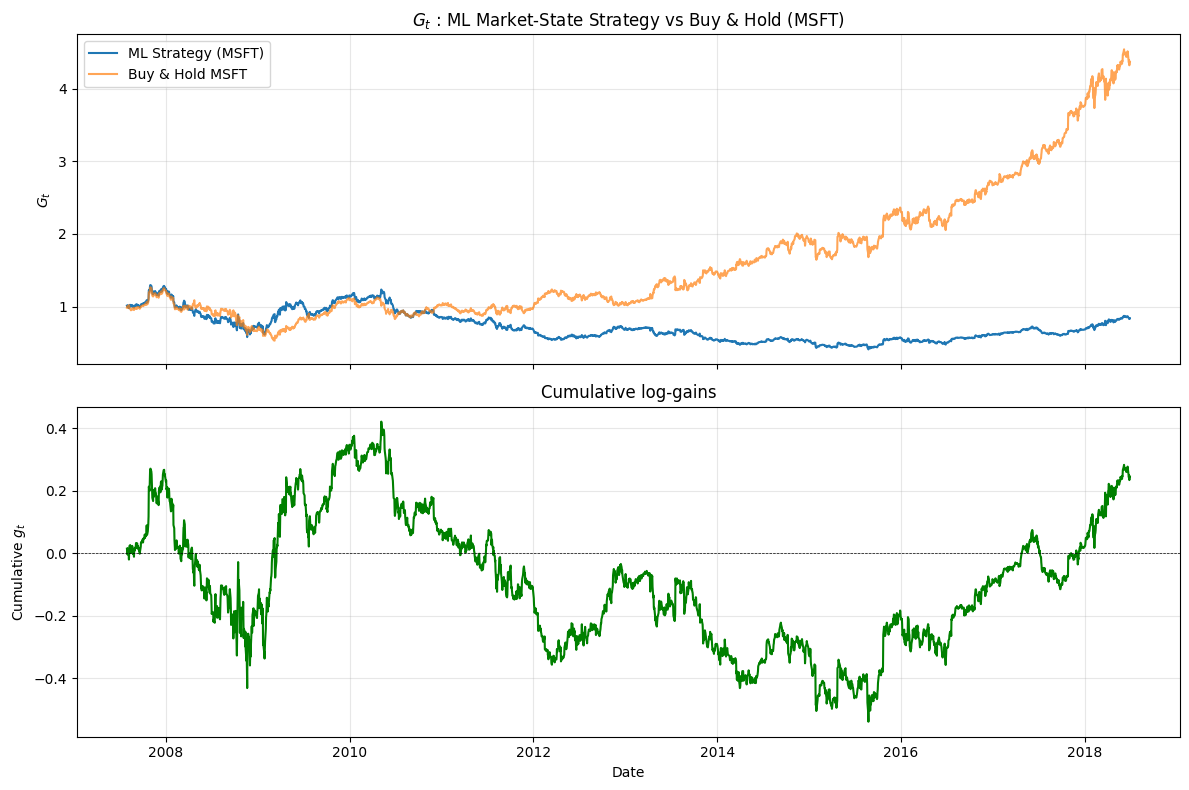

ML Strategy Return: -15.99%
Buy & Hold Return: 336.98%
ML Strategy Sharpe: 0.08
Directional Accuracy: 50.29%


In [20]:
buy_hold = (1 + returns.loc[G_t.index, ticker]).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(G_t.index, G_t.values, label=f"ML Strategy ({ticker})")
axes[0].plot(buy_hold.index, buy_hold.values, label=f"Buy & Hold {ticker}", alpha=0.7)
axes[0].set_ylabel("$G_t$")
axes[0].set_title(f"$G_t$ : ML Market-State Strategy vs Buy & Hold ({ticker})")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(pred_df.index, pred_df["g_t"].cumsum(), color="green")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.5)
axes[1].set_ylabel("Cumulative $g_t$")
axes[1].set_xlabel("Date")
axes[1].set_title("Cumulative log-gains")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

total = G_t.iloc[-1] - 1
bh = buy_hold.iloc[-1] - 1
sharpe_ml = pred_df["g_t"].mean() / pred_df["g_t"].std() * np.sqrt(252)
print(f"ML Strategy Return: {total:.2%}")
print(f"Buy & Hold Return: {bh:.2%}")
print(f"ML Strategy Sharpe: {sharpe_ml:.2f}")
print(f"Directional Accuracy: {accuracy:.2%}")

<blockquote>

En comparant la stratégie ML au buy & hold sur MSFT, les résultats sont défavorables : rendement total de la stratégie $G_T - 1 = -15.99\%$ contre $+336.98\%$ pour le buy & hold, avec un ratio de Sharpe de $0.08$ seulement. La précision directionnelle de $50.29\%$ n'est statistiquement pas différente du hasard ($50\%$), ce qui se traduit par $g_t = x_{t+1} r_{t+1}$ oscillant autour de zéro sans biais positif robuste. Financièrement, MSFT a connu une tendance haussière séculaire sur la période : toute position de vente erronée efface rapidement les gains des positions longues correctes, pénalisant systématiquement la stratégie. Cela confirme que l'approche par états de marché est plus adaptée à des régimes mean-revertants ou sectorisés qu'à la prédiction d'un titre en tendance forte.

Pour aller plus loin, nous allons tester la stratégie sur titre financier. Les banques sont sensibles aux taux d'intérêt, aux cycles économiques et aux crises, ce qui peut créer des régimes de marché plus propices à la prédiction par états de marché.

</blockquote>

In [21]:
ticker = "JPM"

In [22]:
sf_jpm = np.array([encode_state(clean_windows[i], clusterings[i], ticker) for i in range(len(clusterings))])

X_jpm, y_jpm, idx_jpm = [], [], []
for i in range(K, len(clusterings)):
    row = np.concatenate([sf_jpm[i - k] for k in range(K)])
    t1 = window_end_dates[i]
    ix = returns.index.get_loc(t1)
    if ix + 1 < len(returns):
        r_next = returns.iloc[ix + 1][ticker]
        if not np.isnan(r_next):
            X_jpm.append(row); y_jpm.append(1 if r_next >= 0 else -1); idx_jpm.append(i)

X_jpm, y_jpm = np.array(X_jpm), np.array(y_jpm)
y_xgb_jpm = (y_jpm + 1) // 2

raw_jpm = {}
for t in range(min_train, len(X_jpm)):
    clf_jpm = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                             eval_metric="logloss", random_state=42, verbosity=0)
    clf_jpm.fit(X_jpm[:t], y_xgb_jpm[:t])
    p = 1 if clf_jpm.predict(X_jpm[t:t+1])[0] == 1 else -1
    ix = returns.index.get_loc(window_end_dates[idx_jpm[t]])
    for d in range(1, dT + 1):
        if ix + d < len(returns):
            fd = returns.index[ix + d]
            r_act = returns.loc[fd, ticker]
            if not np.isnan(r_act):
                raw_jpm[fd] = (p, r_act)

pred_jpm = pd.DataFrame(raw_jpm, index=["x_t", "r_t"]).T
pred_jpm = pred_jpm[~pred_jpm.index.duplicated(keep="last")].sort_index()
pred_jpm["g_t"] = pred_jpm["x_t"] * pred_jpm["r_t"]
acc_jpm = (np.sign(pred_jpm["r_t"]) == pred_jpm["x_t"]).mean()
print(f"JPM — Directional accuracy: {acc_jpm:.2%}")

JPM — Directional accuracy: 49.67%


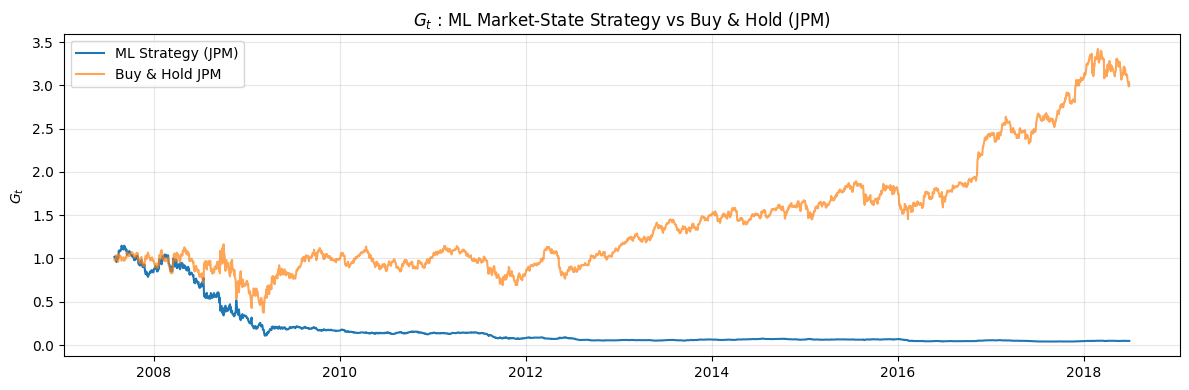

JPM — ML Return: -95.27% | Buy&Hold: 201.58% | Sharpe: -0.44 | Accuracy: 49.67%


In [23]:
G_jpm = (1 + pred_jpm["g_t"]).cumprod()
bh_jpm = (1 + returns.loc[G_jpm.index, ticker]).cumprod()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(G_jpm.index, G_jpm.values, label=f"ML Strategy (JPM)")
ax.plot(bh_jpm.index, bh_jpm.values, label="Buy & Hold JPM", alpha=0.7)
ax.set_ylabel("$G_t$")
ax.set_title("$G_t$ : ML Market-State Strategy vs Buy & Hold (JPM)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

total_jpm  = G_jpm.iloc[-1] - 1
bh_jpm_ret = bh_jpm.iloc[-1] - 1
sharpe_jpm = pred_jpm["g_t"].mean() / pred_jpm["g_t"].std() * np.sqrt(252)
print(f"JPM — ML Return: {total_jpm:.2%} | Buy&Hold: {bh_jpm_ret:.2%} | Sharpe: {sharpe_jpm:.2f} | Accuracy: {acc_jpm:.2%}")

<blockquote>

Les résultats pour JPM sont encore plus défavorables que pour MSFT : $G_T - 1 = -95.27\%$ contre $+201.58\%$ pour le buy & hold, avec un Sharpe de $-0.44$ et une précision directionnelle de $49.67\% < 50\%$. Mathématiquement, une précision inférieure à $50\%$ signifie que le modèle prédit systématiquement le mauvais signe, chaque pari $x_{t+1}$ tend à être anti-corrélé au signe réel de $R_{t+1}$, ce qui rend $g_t = x_{t+1} r_{t+1}$ négatif en moyenne, d'où l'effondrement quasi-total de $G_t$.

Contrairement à l'hypothèse initiale, la cyclicité de JPM n'aide pas la prédiction : la crise de 2008 a d'abord induit un régime de corrélation quasi totale (ARI $\approx 1$, un seul cluster), puis la structure sectorielle a mis plusieurs années à se reconstituer. Le modèle, entraîné sur cet historique chaotique, extrait des features d'états de marché peu informatives sur la direction de JPM seul. Cela illustre une limite fondamentale : l'état de marché global $\mu_t$ encode la structure inter-actifs, pas la dynamique idiosyncratique d'un titre individuel, ce qui rend la prédiction de $\operatorname{sign}(R_{t+1})$ particulièrement difficile pour des actions sensibles aux chocs systémiques.

</blockquote>